# ENN583 - Week 5 Prac

## Metric Motion from 2D-2D Correspondences

Last week, we used the Essential matrix to recover camera rotation and translation direction from two monocular images. The length of the translation was unknown, so we borrowed it from the ground truth.

This week, we will recover that scale from the stereo camera. We will reconstruct 3D points in the current camera frame, transform them using the rotation and translation direction from `recoverPose()`, and optimise a single scale parameter so that the transformed points reproject close to their observed positions in the next image.

### Setting things up

In [2]:
from pathlib import Path
import sys

support_dir = (Path.cwd().resolve().parents[1] / "support")
if str(support_dir) not in sys.path:
    sys.path.insert(0, str(support_dir))
    
import kitti_utils as kitti

import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import least_squares
from spatialmath import SE3

data = kitti.load_kitti_dataset('2011_09_26_drive_0035')
K = data.camera_calibration(camera=2)['K']

### From image matches to metric motion

For two consecutive left-camera images, `findEssentialMat()` and `recoverPose()` give us $R$ and a unit translation direction $t$. Together they map a point from the current camera frame into the next camera frame:

$$X_{k+1} = R X_k + s t.$$

The unknown scalar $s$ is the distance travelled. Stereo disparity gives us metric points $X_k$ in the current camera frame. If we choose the correct $s$, their projections into the next image should agree with the matched image points:

$$\hat{x}_{k+1}(s) = \pi\left(K(RX_k + st)\right).$$

We will ask `scipy.optimize.least_squares` to minimise the reprojection errors.

First we will have to implement the error function. It will take the current estimate for `s` and return a vector of reprojection errors for all points.

In [3]:
def reprojection_residuals(scale, points_3d, observed_pixels, R, t_direction, K):
    """Project the points_3d into the camera positioned at (R, s*t) and return a vector of reprojection errors."""
    
    scale = scale[0]  # The optimiser will pass in a single-element array, so we need to extract the scalar value.
    
    # First project the 3D points into the next camera using the current scale estimate
    # Start by projecting the points into the camera frame, using R, scale, and the direction of translation t_direction. 
    
    # X_cam = ...
    X_cam = R @ points_3d.T + (scale * t_direction)
    
    # Then we can project these points into the image plane, obtaining homogeneous pixel coordinates. 
    # This step uses the camera intrinsics K to map the 3D points in the camera frame into 2D pixel coordinates.
    
    # x_homogeneous = ...
    x_homogeneous = K @ X_cam
         
    # Finally, we can convert these homogeneous coordinates into 2D pixel coordinates by dividing by the last row.
    
    # predicted_pixels = ...
    predicted_pixels = x_homogeneous / x_homogeneous[2:3, :]
    predicted_pixels = predicted_pixels[:2, :].T 
   
    # Now we can compute the residuals by subtracting the observed pixel coordinates from the predicted pixel coordinates.
    
    # residuals = ...
    residuals = predicted_pixels - observed_pixels

    residuals = residuals.flatten()  # The optimiser expects a 1D array of residuals, so we need to flatten the 2D array of residuals into a single vector.   
    
    return residuals

### Estimate motion over the complete sequence

The following loop repeats the pipeline for every consecutive frame pair:

1. Match SIFT features between the current and next left images.
2. Recover $R$ and the direction $t$ using the Essential matrix.
3. Look up stereo disparity at the matched points and reconstruct metric 3D points.
4. Optimise $s$ using reprojection error.
5. Store the resulting metric relative motion.

`recoverPose()` returns the transform from the current camera coordinates to the next camera coordinates, $^{c_{k+1}}T_{c_k}$. We invert it before trajectory accumulation because we need the pose of the next camera expressed in the current camera frame.

In [5]:
# Get the baseline, the focal lengths, and the principal point from the calibration data.
left_calibration = data.camera_calibration(camera=2)
right_calibration = data.camera_calibration(camera=3)
T_right_left = right_calibration['T_cam_imu'] @ np.linalg.inv(left_calibration['T_cam_imu'])
baseline = np.linalg.norm(T_right_left[:3, 3])
fx, fy = K[0, 0], K[1, 1]
cx, cy = K[0, 2], K[1, 2]

# These objects can be reused for every frame.
sift = cv2.SIFT_create()
matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
block_size = 5
stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=16 * 8,
    blockSize=block_size,
    P1=8 * block_size ** 2,
    P2=32 * block_size ** 2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32,
    preFilterCap=63,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY,
)

relative_motions = []
estimated_scales = []
correspondence_counts = []

for frame in range(data.frame_count - 1):
    left_current, right_current = data.stereo(frame)
    left_next, _ = data.stereo(frame + 1)

    left_current = cv2.cvtColor(left_current, cv2.COLOR_RGB2GRAY)
    right_current = cv2.cvtColor(right_current, cv2.COLOR_RGB2GRAY)
    left_next = cv2.cvtColor(left_next, cv2.COLOR_RGB2GRAY)

    disparity = stereo.compute(left_current, right_current).astype(np.float32) / 16.0

    keypoints_current, descriptors_current = sift.detectAndCompute(left_current, None)
    keypoints_next, descriptors_next = sift.detectAndCompute(left_next, None)
    matches = matcher.match(descriptors_current, descriptors_next)

    points_current = np.float32([keypoints_current[match.queryIdx].pt for match in matches])
    points_next = np.float32([keypoints_next[match.trainIdx].pt for match in matches])

    # Estimate the Essential matrix in a RANSAC loop.
    # E, essential_mask = ...
    # make sure to use the essential_mask (i.e. the inlier mask) in the next step to filter out outliers before estimating the scale.
    # _, R, t_direction, pose_mask = ...

    # TODO: Implement this solution.
    E, essential_mask = cv2.findEssentialMat(
        points_current, points_next, cameraMatrix=K, method=cv2.RANSAC,
        prob=0.999, threshold=1.0
    )
    number_of_essential_inliers = np.count_nonzero(essential_mask)

    _, R, t_direction, pose_mask = cv2.recoverPose(
        E, points_current, points_next, cameraMatrix=K, mask=essential_mask.copy()
    )

    # Keep only matches that were inliers when estimating the Essential Matrix.
    inliers = essential_mask.ravel().astype(bool)
    points_current = points_current[inliers]
    observed_pixels = points_next[inliers]

    # Look up disparity at each current-image feature.
    u = points_current[:, 0].astype(int)
    v = points_current[:, 1].astype(int)
    disparities = disparity[v, u]

    # Reject invalid and very small disparities before calculating depth.
    valid_disparity = np.isfinite(disparities) & (disparities > 1.0)
    points_current = points_current[valid_disparity]
    observed_pixels = observed_pixels[valid_disparity]
    disparities = disparities[valid_disparity]

    # Reconstruct each point in the current left-camera frame.
    # Z = ...
    # X = ...
    # Y = ...

    # TODO: Implement this solution.
    Z = (fx * baseline) / disparities
    X = (points_current[:, 0] - cx) * Z / fx
    Y = (points_current[:, 1] - cy) * Z / fy

    points_3d = np.column_stack((X, Y, Z))

    # Very distant points have uncertain stereo depth, so exclude them.
    valid = np.isfinite(points_3d).all(axis=1) & (Z < 80.0)
    points_3d = points_3d[valid]
    observed_pixels = observed_pixels[valid]
    correspondence_counts.append(len(points_3d))

    # Translation is unreliable when there is too little parallax. In that
    # case, record no motion rather than optimising from too few points.
    if len(points_3d) < 6:
        print(f'Frame {frame}: too few correspondences; using zero motion')
        estimated_scales.append(0.0)
        relative_motions.append(SE3())
        continue

    # Now we are ready to estimate the scale of the translation vector. 
    # We do this by optimising the reprojection error of the 3D points into the next camera, 
    # using the current rotation and translation direction, and varying the scale of the translation vector.
    # We call SciPy's least_squares optimiser to do this, passing in the function that computes the residuals, an initial guess for the scale, and the other fixed parameters needed to compute the residuals.
    
    result = least_squares(                 # this is scipy's least squares optimiser
        reprojection_residuals,             # the function that computes the residuals
        x0=np.array([0.5]),                 # the initial guess for the scale
        bounds=(0.0, 2.0),                  # optionally the optimiser can be constrained to a range of values
        loss='linear',                      # the objective function used. `linear` means that the optimiser will minimise the sum of squared residuals. Other options to try: `soft_l1`, `huber`, and `cauchy`, which are more robust to outliers that might still be in the data, even after initial filtering with RANSAC.
        args=(points_3d, observed_pixels, R, t_direction, K),       # the arguments passed on to to the residuals function. Notice that the first argument is the scale, which is the variable being optimised. The rest are fixed values that are passed to the residuals function.
    )
    scale = result.x[0]    # the optimiser returns an array of values, but we only have one variable, so we take the first element.
    # inspect the other attributes of the result object to see what else is available, e.g. result.success, result.cost, result.fun, etc.

    # remember the estimated scale for this camera frame pair, so we can plot it later.
    estimated_scales.append(scale)

    # R and scale*t map current-camera points into the next camera.
    # Invert this transform to obtain the pose used for accumulation.
    T_next_current = SE3.Rt(R, scale * t_direction.flatten())
    relative_motions.append(T_next_current.inv())

    if (frame + 1) % 25 == 0:
        print(f'Processed {frame + 1} frame pairs')

Processed 25 frame pairs
Processed 50 frame pairs
Processed 75 frame pairs
Processed 100 frame pairs
Processed 125 frame pairs


### Visualise and evaluate the result

The relative motions are expressed in camera coordinates. As in Week 4, we change their basis into the KITTI IMU frame before accumulating the trajectory. Ground truth is used only for evaluation; it is not used to estimate scale.

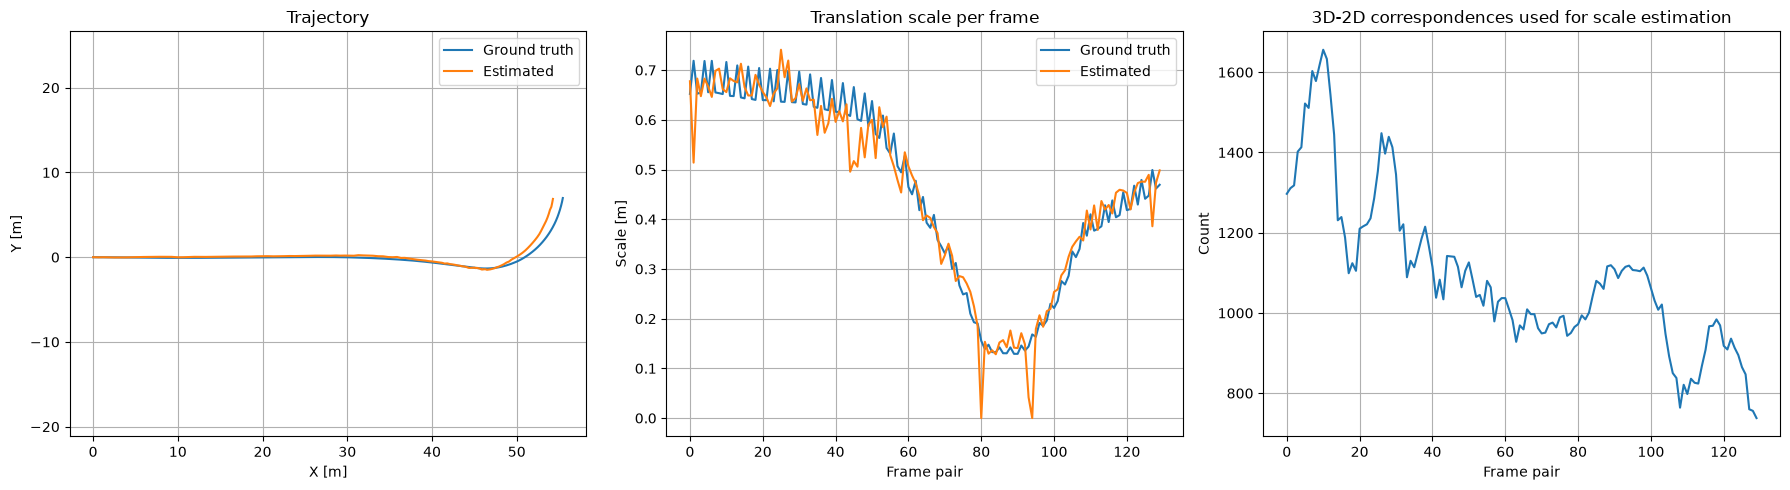

Absolute Trajectory Error: 0.8550 m
Translation Scale RMSE:    0.0498 m


In [6]:
T_cam_imu_matrix = data.camera_calibration(camera=2)['T_cam_imu']
T_cam_imu = SE3.Rt(
    T_cam_imu_matrix[:3, :3], T_cam_imu_matrix[:3, 3], check=False
)

estimated_trajectory = [SE3()]
for motion in relative_motions:
    motion_in_imu = T_cam_imu.inv() @ motion @ T_cam_imu
    estimated_trajectory.append(estimated_trajectory[-1] @ motion_in_imu)

estimated_positions = np.array([pose.t for pose in estimated_trajectory])
ground_truth_trajectory = [
    data.ground_truth_pose(frame) for frame in range(data.frame_count)
]
ground_truth_positions = np.array([pose.t for pose in ground_truth_trajectory])
ground_truth_scales = np.linalg.norm(
    np.diff(ground_truth_positions, axis=0), axis=1
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ground_truth_positions[:, 0], ground_truth_positions[:, 1], label='Ground truth')
axes[0].plot(estimated_positions[:, 0], estimated_positions[:, 1], label='Estimated')
axes[0].set_title('Trajectory')
axes[0].set_xlabel('X [m]')
axes[0].set_ylabel('Y [m]')
axes[0].axis('equal')
axes[0].grid()
axes[0].legend()

axes[1].plot(ground_truth_scales, label='Ground truth')
axes[1].plot(estimated_scales, label='Estimated')
axes[1].set_title('Translation scale per frame')
axes[1].set_xlabel('Frame pair')
axes[1].set_ylabel('Scale [m]')
axes[1].grid()
axes[1].legend()

axes[2].plot(correspondence_counts)
axes[2].set_title('3D-2D correspondences used for scale estimation')
axes[2].set_xlabel('Frame pair')
axes[2].set_ylabel('Count')
axes[2].grid()

plt.tight_layout()
plt.show()

errors = np.linalg.norm(estimated_positions - ground_truth_positions, axis=1)
ate = np.sqrt(np.mean(errors ** 2))
scale_rmse = np.sqrt(np.mean((np.array(estimated_scales) - ground_truth_scales) ** 2))
print(f'Absolute Trajectory Error: {ate:.4f} m')
print(f'Translation Scale RMSE:    {scale_rmse:.4f} m')

### Reflection questions

1. Why can the Essential matrix recover the direction of translation but not its magnitude?
2. Why does stereo disparity allow the optimisation to recover scale in metres?
3. What happens to depth uncertainty as disparity approaches zero?
4. Compare the estimated scale with the ground truth. Which frame pairs give poor estimates, and what might be happening in those images?